Make J-plot from SOHO/LASCO C2 images to track the speed of a solar feature

In [1]:
import warnings
warnings.filterwarnings('ignore')

# import matplotlib
# matplotlib.use('nbAgg')

import os
import glob
import pickle
import numpy as np
import pandas as pd
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator
from scipy.interpolate import UnivariateSpline
import astropy.io.fits as fits
import astropy.units as u
from astropy.coordinates import SkyCoord
import sunpy.map
# from PIL import Image
# import matplotlib.colors as colors
from astropy.visualization import ImageNormalize, SqrtStretch, LogStretch
from scipy import stats
import sunpy.sun.constants as const
from scipy.interpolate import interp1d
from sunpy.coordinates import SphericalScreen
from tqdm import tqdm

import sys
# Construct the full path to the scripts directory
script_path = os.path.abspath('./scripts')

# Add the scripts directory to sys.path
if script_path not in sys.path:
    sys.path.append(script_path)

import solar_data_utils as myfuncs
# Reload to update with new changes
import importlib
importlib.reload(myfuncs)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

data_dir = '/home/mnedal/data'
savedir = '/home/mnedal/repos/dias_work'

In [2]:
detector = 'C2'
os.makedirs(f'{savedir}/jplots/lasco_{detector}/clicking', exist_ok=True)

In [3]:
lasco_c2_map_objects = myfuncs.load_lasco(data_dir=data_dir,
                                          start='2024-05-14T17:30:00',
                                          end='2024-05-14T20:00:00',
                                          detector='C2')

LASCO C2 image 0 is done
LASCO C2 image 1 is done
LASCO C2 image 2 is done
LASCO C2 image 3 is done
LASCO C2 image 4 is done
LASCO C2 image 5 is done
LASCO C2 image 6 is done
LASCO C2 image 7 is done
LASCO C2 image 8 is done
LASCO C2 image 9 is done
LASCO C2 image 10 is done
LASCO C2 image 11 is done
LASCO C2 image 12 is done
LASCO C2 image 13 is done
LASCO C2 image 14 is done
LASCO C2 image 15 is done
LASCO C2 image 16 is done
LASCO C2 image 17 is done
LASCO C2 image 18 is done
LASCO C2 image 19 is done
LASCO C2 image 20 is done
LASCO C2 image 21 is done
LASCO C2 image 22 is done
LASCO C2 image 23 is done
LASCO C2 image 24 is done
LASCO C2 image 25 is done
LASCO C2 image 26 is done
LASCO C2 image 27 is done
LASCO C2 image 28 is done
LASCO C2 image 29 is done
LASCO C2 image 30 is done
LASCO C2 image 31 is done
LASCO C2 image 32 is done
LASCO C2 image 33 is done
LASCO C2 image 34 is done
LASCO C2 image 35 is done
LASCO C2 image 36 is done
LASCO C2 image 37 is done
LASCO C2 image 38 is d

In [4]:
# remove redundant images
clean_maps_c2 = myfuncs.remove_redundant_maps(lasco_c2_map_objects)

print(f'Before:\nLASCO C2: {len(lasco_c2_map_objects)} images\n')
print(f'After:\nLASCO C2: {len(clean_maps_c2)} images')

Before:
LASCO C2: 150 images

After:
LASCO C2: 13 images


2025-03-14 16:02:50 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2025-03-14 16:02:50 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


2025-03-14 16:02:51 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


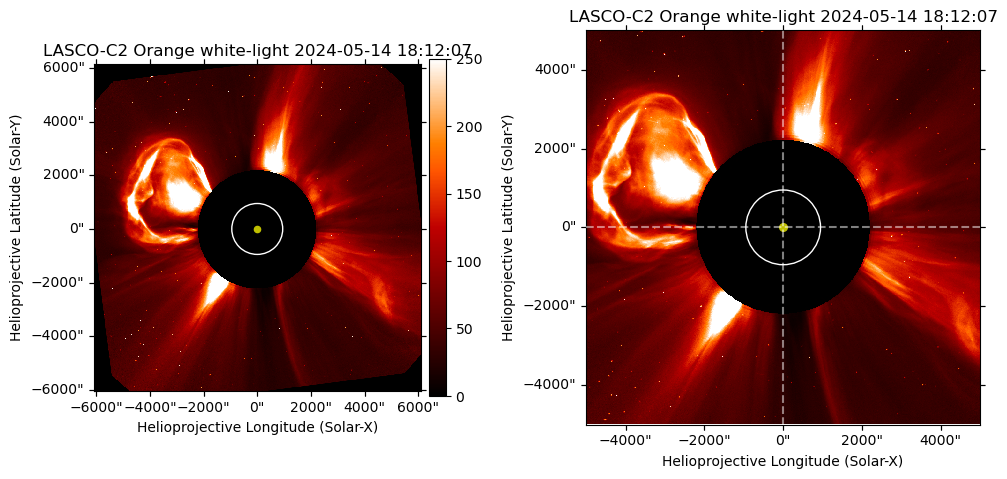

In [44]:
# Test plot ...
fig = plt.figure(figsize=[10,5])

m = clean_maps_c2[4]
ax = fig.add_subplot(121, projection=m)
img = m.plot(axes=ax)
m.draw_limb()
pixel_coords = m.wcs.world_to_pixel(SkyCoord(0*u.arcsec, 0*u.arcsec, frame=m.coordinate_frame))
x_pixel, y_pixel = pixel_coords
ax.scatter(x_pixel, y_pixel, c='y', s=20)
ax.grid(False)
plt.colorbar(img, pad=0.02, shrink=0.8)

m = clean_maps_c2[4]
crop_length = 5000
top_right = SkyCoord(crop_length * u.arcsec, crop_length * u.arcsec, frame=m.coordinate_frame)
bottom_left = SkyCoord(-crop_length * u.arcsec, -crop_length * u.arcsec, frame=m.coordinate_frame)
submap = m.submap(bottom_left, top_right=top_right)
ax = fig.add_subplot(122, projection=submap)
submap.plot(axes=ax)
submap.draw_limb()
pixel_coords = submap.wcs.world_to_pixel(SkyCoord(0*u.arcsec, 0*u.arcsec, frame=submap.coordinate_frame))
x_pixel, y_pixel = pixel_coords
ax.scatter(x_pixel, y_pixel, c='y', s=30)
ax.axvline(x=x_pixel, color='w', linestyle='--', alpha=0.5)
ax.axhline(y=y_pixel, color='w', linestyle='--', alpha=0.5)
ax.grid(False)

fig.tight_layout()
plt.show()

In [5]:
# make run-diff maps
m_seq_runratio_c2 = myfuncs.apply_runratio(clean_maps_c2)

Applying running ratio ...:  92%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏         | 12/13 [00:00<00:00, 82.06it/s]


In [6]:
# %matplotlib inline

2026-04-09 11:34:33 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


2026-04-09 11:34:34 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


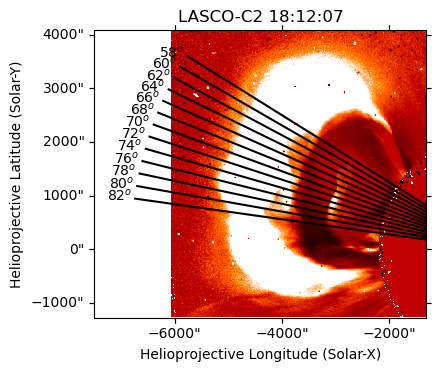

In [7]:
slits = True
centered_list = myfuncs.generate_centered_list(160, 2, 6)
position_angles = []

fig = plt.figure(figsize=[7,7])

m = m_seq_runratio_c2[3]
ax = fig.add_subplot(111, projection=m)
img = m.plot(axes=ax)
m.draw_limb()
ax.grid(False)
ax.set_title(m.latex_name.replace('Orange white-light 2024-05-14 ', ''))
# plt.colorbar(img, pad=0.02, shrink=0.8)

if slits:
    for value in centered_list:
        line = myfuncs.plot_line(angle_deg=value, length=6800, map_obj=m)
        ax.plot_coord(line, color='black')
        
        # Plot the number at the end of the line
        # Convert SkyCoord to pixel coordinates for plotting text
        line_lon, line_lat = line.Tx, line.Ty
        end_point_pixel = m.world_to_pixel(SkyCoord(line_lon[1], line_lat[1], frame=m.coordinate_frame))

        # rename the angles to be position angles, instead of geometric angles
        PA_value = value - 90
        position_angles.append(PA_value)
        
        # Display the number at the end point
        ax.text(end_point_pixel.x.value - 25, end_point_pixel.y.value + 5, f'{PA_value}$^o$',
                color='black', fontsize=10, ha='center', va='center')

ax.set_xlim(left=-120, right=400)
ax.set_ylim(bottom=400, top=850)
fig.tight_layout()
# fig.savefig(f"{data_dir}/LASCO_{m.meta['detector']}_{m.meta['date_obs'].replace('/','-')}T{m.meta['time_obs']}.pdf", format='pdf', bbox_inches='tight')
plt.show()

2025-03-14 16:03:52 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


2025-03-14 16:03:52 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


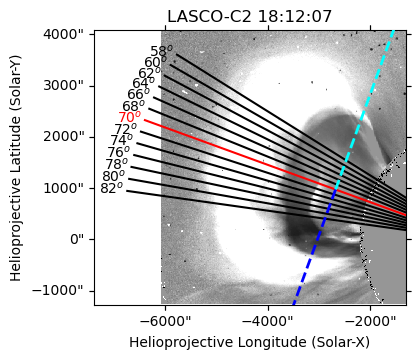

In [48]:
# plot lateral slits for upper flank and lower flank
fig = plt.figure(figsize=[7,7])

m = m_seq_runratio_c2[3]
ax = fig.add_subplot(111, projection=m)
img = m.plot(axes=ax)
m.draw_limb()
ax.grid(False)
ax.set_title(m.latex_name.replace('Orange white-light 2024-05-14 ', ''))

for value in centered_list:
    # rename the angles to be position angles, instead of geometric angles
    PA_value = value - 90
    position_angles.append(PA_value)
    
    # if PA_value in [76,74,72,70,68,66,64]:
    if PA_value == 70:
        text_and_slit_color = 'red'
    else:
        text_and_slit_color = 'black'
    
    line = myfuncs.plot_line(angle_deg=value, length=6800, map_obj=m)
    ax.plot_coord(line, color=text_and_slit_color)
    
    # Plot the number at the end of the line
    # Convert SkyCoord to pixel coordinates for plotting text
    line_lon, line_lat = line.Tx, line.Ty
    end_point_pixel = m.world_to_pixel(SkyCoord(line_lon[1], line_lat[1], frame=m.coordinate_frame))
    
    # Display the number at the end point
    ax.text(end_point_pixel.x.value - 25, end_point_pixel.y.value + 5, f'{PA_value}$^o$',
            color=text_and_slit_color, fontsize=10, ha='center', va='center')

# Define lateral slits
solar_radius_arcsec = m.rsun_obs.to_value(u.arcsec)  # Solar radius in arcsec
shift_distance = 3 * solar_radius_arcsec             # Shift by 3 solar radii
perpendicular_angle = 160 - 90                       # 70° (perpendicular to 160°)
slit_length = 7700

# Compute the shift position along the main slit direction (160°)
shift_x = shift_distance * np.cos(np.deg2rad(160))
shift_y = shift_distance * np.sin(np.deg2rad(160))

# Compute lateral slit start and end points (starting at main slit)
start_x = shift_x
start_y = shift_y
end_x1  = start_x + slit_length * np.cos(np.deg2rad(perpendicular_angle))
end_y1  = start_y + slit_length * np.sin(np.deg2rad(perpendicular_angle))
end_x2  = start_x - slit_length * np.cos(np.deg2rad(perpendicular_angle))
end_y2  = start_y - slit_length * np.sin(np.deg2rad(perpendicular_angle))

# Convert to SkyCoord
upper_flank = SkyCoord([start_x, end_x1] * u.arcsec, [start_y, end_y1] * u.arcsec, frame=m.coordinate_frame)
lower_flank = SkyCoord([start_x, end_x2] * u.arcsec, [start_y, end_y2] * u.arcsec, frame=m.coordinate_frame)

# Plot lateral slits (starting at main slit and extending outward)
ax.plot_coord(upper_flank, color='cyan', linewidth=2, linestyle='dashed')
ax.plot_coord(lower_flank, color='blue', linewidth=2, linestyle='dashed')

# # Optional: Add labels at the ends
# for lateral_line, label_offset in zip([upper_flank, lower_flank], [-20, 20]):
#     lat_line_lon, lat_line_lat = lateral_line.Tx, lateral_line.Ty
#     lat_end_pixel = m.world_to_pixel(SkyCoord(lat_line_lon[1], lat_line_lat[1], frame=m.coordinate_frame))
#     ax.text(lat_end_pixel.x.value + label_offset, lat_end_pixel.y.value + 5, f'{perpendicular_angle}$^o$',
#             color='blue', fontsize=10, ha='center', va='center')

ax.set_xlim(left=-110, right=400)
ax.set_ylim(bottom=400, top=850)
fig.tight_layout()
plt.show()

In [50]:
def plot_lateral_slits(map_obj, shift_radii=3, central_angle=160, slit_length=7700):
    """
    Generate two lateral slits perpendicular to a given central slit and shifted by a specified 
    number of solar radii from the solar disk center.

    Parameters:
    ----------
    map_obj : sunpy.map.Map
        The solar map on which the slits are defined.
    shift_radii : float, optional
        The shift distance in solar radii from the center of the Sun (default is 3 solar radii).
    central_angle : float, optional
        The angle (in degrees) defining the main slit direction (default is 160°).
    slit_length : float, optional
        The length of each lateral slit in arcseconds (default is 3400 arcsec per side).

    Returns:
    -------
    tuple of SkyCoord
        (upper_lateral_slit, lower_lateral_slit) representing the two lateral slits.
    """
    # Convert shift distance from solar radii to arcseconds
    shift_distance = shift_radii * map_obj.rsun_obs.to_value(u.arcsec)
    
    # Compute the perpendicular angle (90° offset from central slit)
    lateral_angle = central_angle - 90  # Perpendicular to central angle
    
    # Compute the shift position along the central slit direction
    shift_x = shift_distance * np.cos(np.deg2rad(central_angle))
    shift_y = shift_distance * np.sin(np.deg2rad(central_angle))
    
    # Compute lateral slit start and end points
    end_x1 = shift_x + slit_length * np.cos(np.deg2rad(lateral_angle))
    end_y1 = shift_y + slit_length * np.sin(np.deg2rad(lateral_angle))
    end_x2 = shift_x - slit_length * np.cos(np.deg2rad(lateral_angle))
    end_y2 = shift_y - slit_length * np.sin(np.deg2rad(lateral_angle))
    
    # Convert to SkyCoord
    upper_flank = SkyCoord([shift_x, end_x1] * u.arcsec, [shift_y, end_y1] * u.arcsec, frame=map_obj.coordinate_frame)
    lower_flank = SkyCoord([shift_x, end_x2] * u.arcsec, [shift_y, end_y2] * u.arcsec, frame=map_obj.coordinate_frame)
    
    return upper_flank, lower_flank

## J-Maps for LASCO C2

In [49]:
# # This is based on the "SphericalScreen" method ... doesn't seem correct!

# # Make a dictionary to hold the lists of lists
# intensity_dict = {}
# distances_dict = {}
# output_obj     = {}

# # Initialize each key with an empty list
# for value in centered_list:
#     intensity_dict[f'intensity_{value}deg'] = []
#     distances_dict[f'distances_{value}deg'] = []
#     output_obj[f'intensity_{value}deg']     = []
#     output_obj[f'distances_{value}deg']     = []

# output_obj['time']       = []
# output_obj['map_obj']    = []
# output_obj['instrument'] = []

# with tqdm(total=len(m_seq_runratio_c2), desc='Doing J-Maps ...') as pbar:
#     for i, m in enumerate(m_seq_runratio_c2):
#         print(f'Working on map {i} ..')

#         fig = plt.figure(figsize=[7,7])
#         ax = fig.add_subplot(111, projection=m)
#         m.plot(axes=ax)

#         for value in centered_list:
#             line = myfuncs.plot_line(angle_deg=value, length=6800, map_obj=m)
#             ax.plot_coord(line, color='black')
            
#             # Plot the number at the end of the line
#             # Convert SkyCoord to pixel coordinates for plotting text
#             line_lon, line_lat = line.Tx, line.Ty
#             end_point_pixel = m.world_to_pixel(SkyCoord(line_lon[1], line_lat[1], frame=m.coordinate_frame))

#             # Display the number at the end point
#             ax.text(end_point_pixel.x.value - 20, end_point_pixel.y.value + 20, f'{value}$^o$',
#                     color='black', fontsize=10, ha='center', va='center')
            
#             # extract and stack intensity along the slit
#             with SphericalScreen(m.observer_coordinate):
#                 slit_pixelated = sunpy.map.pixelate_coord_path(m, line)
#             # Create mask to identify valid coordinates
#             valid_mask = sunpy.map.contains_coordinate(m, slit_pixelated)
#             # Apply the mask to filter valid coordinates
#             valid_coords = slit_pixelated[valid_mask]
#             # Pass those coordinates to extract the intensities for those map pixels
#             intensity = sunpy.map.sample_at_coords(m, valid_coords)
#             # Calculate the angular separation between the first point
#             # and every other coordinate we extracted
#             angular_distances = valid_coords[:-1].separation(valid_coords[1:])
#             # Compute the cumulative sum of the angular distances
#             cumulative_distances = np.cumsum(angular_distances)
#             # Add 0 at the start to represent the distance at the first point
#             cumulative_distances_with_start = np.insert(cumulative_distances, 0, 0*u.arcsec)            
#             # interpolate intensity along angular distance
#             f_interp = interp1d(cumulative_distances_with_start, intensity.value,
#                                 fill_value='extrapolate', kind='linear')
#             intensity_interp = f_interp(cumulative_distances_with_start)
#             # add the intensity array to the list
#             intensity_dict[f'intensity_{value}deg'].append(u.Quantity(intensity_interp, intensity.unit))
#             distances_dict[f'distances_{value}deg'].append(cumulative_distances_with_start.to('arcsec'))
    
#         output_obj['time'].append(m.date.iso)
#         output_obj['map_obj'].append(m)
#         output_obj['instrument'].append(f"{m.meta['instrume']}_{m.meta['detector']}")

#         fig.tight_layout()
#         plt.show()
#         pbar.update(1)

Working on map 0 ..


2025-03-14 17:11:37 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


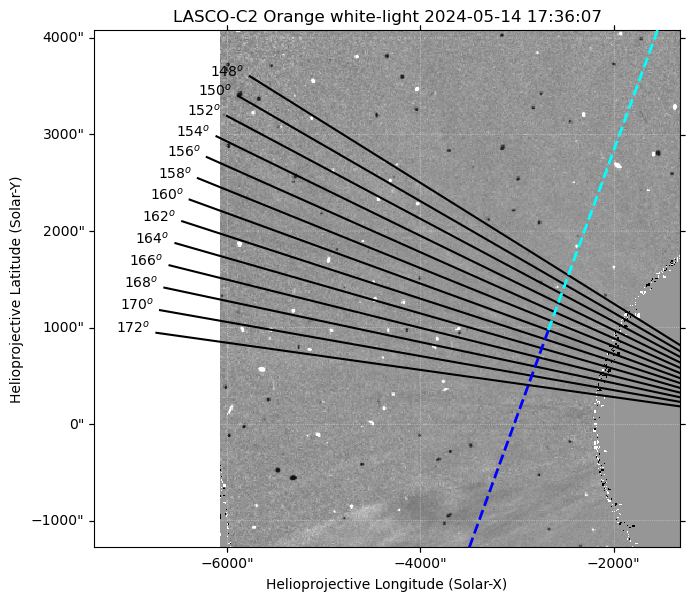

Working on map 1 ..


2025-03-14 17:11:39 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


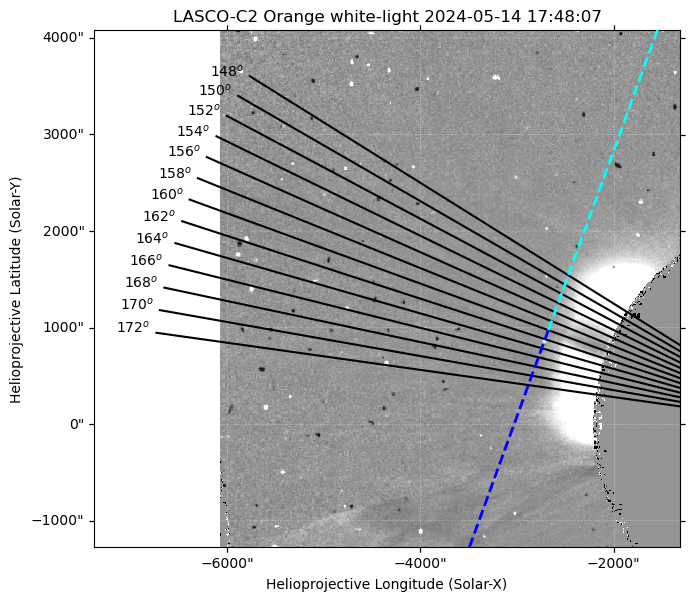

Working on map 2 ..


2025-03-14 17:11:42 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


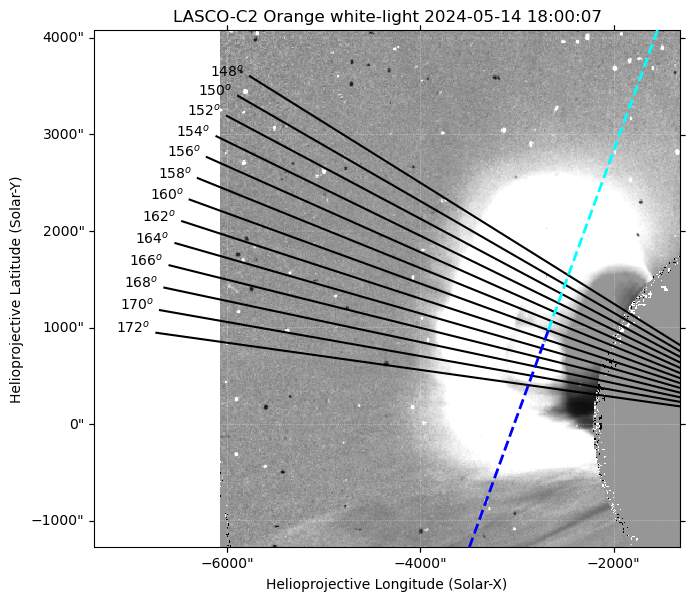

Working on map 3 ..


2025-03-14 17:11:44 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f7e56a6da50>>
Traceback (most recent call last):
  File "/mnt/mnedal_data/anaconda3/envs/dias/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

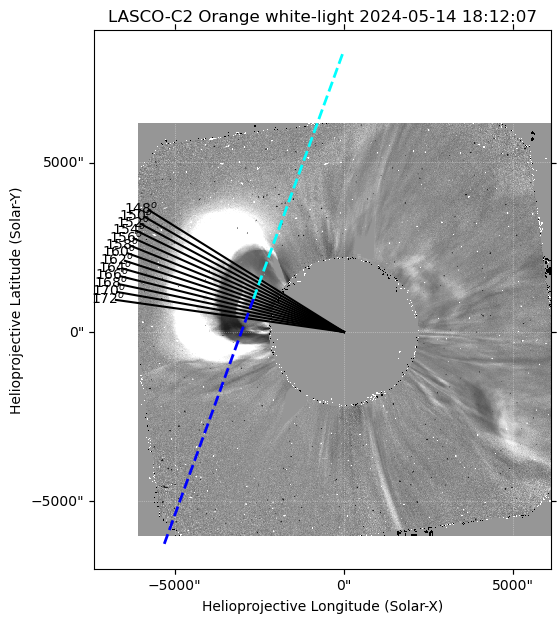

In [79]:
# My classic way ...

# Make a dictionary to hold the lists of lists
intensity_dict = {}
distances_dict = {}
output_obj     = {}

# Initialize each key with an empty list
for value in centered_list:
    intensity_dict[f'intensity_{value}deg'] = []
    distances_dict[f'distances_{value}deg'] = []
    output_obj[f'intensity_{value}deg']     = []
    output_obj[f'distances_{value}deg']     = []
    # for lateral expansion
    intensity_dict['upper_flank'] = []
    distances_dict['upper_flank'] = []
    intensity_dict['lower_flank'] = []
    distances_dict['lower_flank'] = []

output_obj['time']       = []
output_obj['map_obj']    = []
output_obj['instrument'] = []

for i, m in enumerate(m_seq_runratio_c2):
    print(f'Working on map {i} ..')
    
    fig = plt.figure(figsize=[7,7])
    ax = fig.add_subplot(111, projection=m)
    m.plot(axes=ax)
    
    for value in centered_list:
        # for radial slits ...
        line = myfuncs.plot_line(angle_deg=value, length=6800, map_obj=m)
        ax.plot_coord(line, color='black')
        # Convert SkyCoord to pixel coordinates for plotting text
        line_lon, line_lat = line.Tx, line.Ty
        end_point_pixel = m.world_to_pixel(SkyCoord(line_lon[1], line_lat[1], frame=m.coordinate_frame))
        # Display the number at the end point
        ax.text(end_point_pixel.x.value-20, end_point_pixel.y.value+5, f'{value}$^o$',
                color='black', fontsize=10, ha='center', va='center')
        # obtain the coordinates of the map pixels that intersect that path
        intensity_coords_slit = sunpy.map.pixelate_coord_path(m, line)
        # Make mask to identify valid coordinates within the map's boundaries
        valid_mask = sunpy.map.contains_coordinate(m, intensity_coords_slit)
        # Apply the mask to filter valid coordinates
        valid_coords = intensity_coords_slit[valid_mask]
        # Pass those coordinates to extract the values for those map pixels
        intensity_slit = sunpy.map.sample_at_coords(m, valid_coords)
        # Calculate the angular separation between the first point and every other coordinate we extracted
        angular_separation_slit = valid_coords.separation(valid_coords[0]).to(u.arcsec)
        # Append the values to the lists
        intensity_dict[f'intensity_{value}deg'].append(list(intensity_slit.value))
        distances_dict[f'distances_{value}deg'].append(list(angular_separation_slit.value))
        # intensity_dict[f'intensity_{angle}deg'].append(intensity_slit.value)
        # distances_dict[f'distances_{angle}deg'].append(angular_separation_slit.value)
        
    # for lateral slits ...
    upper_flank, lower_flank = plot_lateral_slits(m, shift_radii=3, central_angle=160, slit_length=7700)
    ax.plot_coord(upper_flank, color='cyan', linewidth=2, linestyle='dashed')
    ax.plot_coord(lower_flank, color='blue', linewidth=2, linestyle='dashed')
    # obtain the coordinates of the map pixels that intersect these paths
    intensity_coords_upper_flank = sunpy.map.pixelate_coord_path(m, upper_flank)
    intensity_coords_lower_flank = sunpy.map.pixelate_coord_path(m, lower_flank)
    # Make mask to identify valid coordinates within the map's boundaries
    valid_mask_upper_flank = sunpy.map.contains_coordinate(m, intensity_coords_upper_flank)
    valid_mask_lower_flank = sunpy.map.contains_coordinate(m, intensity_coords_lower_flank)
    # Apply the mask to filter valid coordinates
    valid_coords_upper_flank = intensity_coords_upper_flank[valid_mask_upper_flank]
    valid_coords_lower_flank = intensity_coords_lower_flank[valid_mask_lower_flank]
    # Pass those coordinates to extract the values for those map pixels
    intensity_upper_flank = sunpy.map.sample_at_coords(m, valid_coords_upper_flank)
    intensity_lower_flank = sunpy.map.sample_at_coords(m, valid_coords_lower_flank)
    # Calculate the angular separation between the first point and every other coordinate we extracted
    angular_separation_upper_flank = valid_coords_upper_flank.separation(valid_coords_upper_flank[0]).to(u.arcsec)
    angular_separation_lower_flank = valid_coords_lower_flank.separation(valid_coords_lower_flank[0]).to(u.arcsec)
    # Append the values to the lists
    intensity_dict['upper_flank'].append(list(intensity_upper_flank.value))
    intensity_dict['lower_flank'].append(list(intensity_lower_flank.value))
    distances_dict['upper_flank'].append(list(angular_separation_upper_flank.value))
    distances_dict['lower_flank'].append(list(angular_separation_lower_flank.value))
    
    output_obj['time'].append(m.date.iso)
    output_obj['map_obj'].append(m)
    output_obj['instrument'].append(f"{m.meta['instrume']}_{m.meta['detector']}")
    
    fig.tight_layout()
    plt.show()

2025-03-14 17:20:11 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


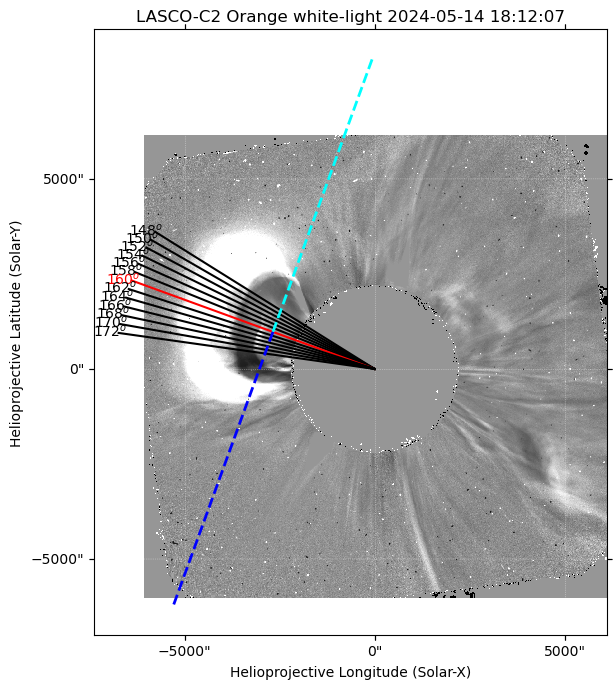

In [83]:
# Example: show one frame
m = m_seq_runratio_c2[3]
    
fig = plt.figure(figsize=[7,7])
ax = fig.add_subplot(111, projection=m)
m.plot(axes=ax)

for value in centered_list:
    if value == 160:
        text_and_slit_color = 'red'
    else:
        text_and_slit_color = 'black'
    # for radial slits ...
    line = myfuncs.plot_line(angle_deg=value, length=6800, map_obj=m)
    ax.plot_coord(line, color=text_and_slit_color)
    # Convert SkyCoord to pixel coordinates for plotting text
    line_lon, line_lat = line.Tx, line.Ty
    end_point_pixel = m.world_to_pixel(SkyCoord(line_lon[1], line_lat[1], frame=m.coordinate_frame))
    # Display the number at the end point
    ax.text(end_point_pixel.x.value-20, end_point_pixel.y.value+5, f'{value}$^o$',
            color=text_and_slit_color, fontsize=10, ha='center', va='center')
    
# for lateral slits ...
upper_flank, lower_flank = plot_lateral_slits(m, shift_radii=3, central_angle=160, slit_length=7700)
ax.plot_coord(upper_flank, color='cyan', linewidth=2, linestyle='dashed')
ax.plot_coord(lower_flank, color='blue', linewidth=2, linestyle='dashed')

# ax.set_xlim(left=-100, right=400)
# ax.set_ylim(bottom=400, top=850)
fig.tight_layout()
plt.show()

In [69]:
datenum_arr = [mdates.date2num(pd.Timestamp(str(t))) for t in output_obj['time']]

for value in centered_list:
    intens = np.array(intensity_dict[f'intensity_{value}deg']).T
    height = np.array(distances_dict[f'distances_{value}deg'][0])
    output_obj[f'intensity_{value}deg'].append(intens)
    output_obj[f'distances_{value}deg'].append(height)

In [70]:
angle = 154

height = output_obj[f'distances_{angle}deg'][0].copy()
intens = output_obj[f'intensity_{angle}deg'][0].copy()

lasco_map = output_obj['map_obj'][0]

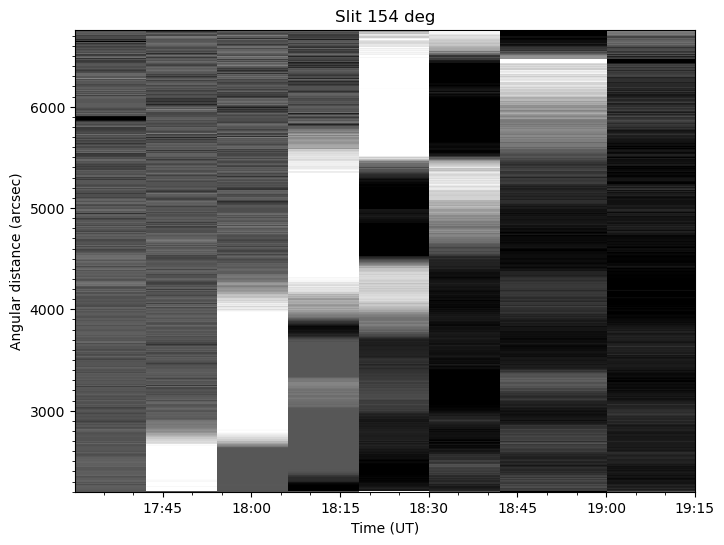

In [71]:
fig = plt.figure(figsize=[8,6])
ax = fig.add_subplot(111)
ax.pcolormesh(datenum_arr, height, intens, vmin=0.7, vmax=1.8, cmap='Greys_r')
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Angular distance (arcsec)')
ax.set_title(f'Slit {angle} deg')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_minor_locator(AutoMinorLocator(n=3))
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlim(right=pd.Timestamp(f"{output_obj['time'][0].split(' ')[0]} 19:15:00"))
ax.set_ylim(bottom=2200)
plt.show()

2025-03-14 17:06:14 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


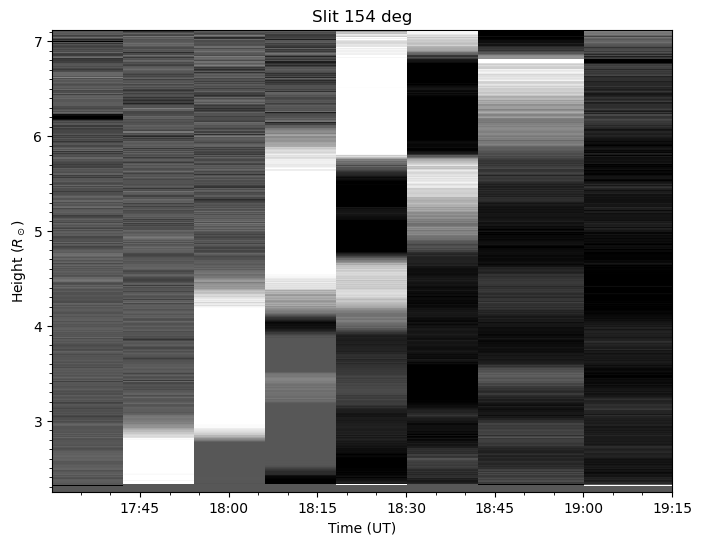

In [72]:
# conversion from arcsec to solar radius
dist_rsun = height/lasco_map.rsun_obs.value

fig = plt.figure(figsize=[8,6])
ax = fig.add_subplot(111)
ax.pcolormesh(datenum_arr, dist_rsun, intens, vmin=0.7, vmax=1.8, cmap='Greys_r')
ax.set_xlabel('Time (UT)')
ax.set_ylabel(r'Height ($R_\odot$)')
ax.set_title(f'Slit {angle} deg')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_minor_locator(AutoMinorLocator(n=3))
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlim(right=pd.Timestamp(f"{output_obj['time'][0].split(' ')[0]} 19:15:00"))
ax.set_ylim(bottom=2.25)
plt.show()

In [73]:
# J-plots for the flank slits
intens_upper_flank = np.array(intensity_dict['upper_flank']).T
intens_lower_flank = np.array(intensity_dict['lower_flank']).T
distance_upper_flank = np.array(distances_dict['upper_flank'][0])
distance_lower_flank = np.array(distances_dict['lower_flank'][0])

In [74]:
intens_upper_flank.shape, distance_upper_flank.shape, len(datenum_arr)

((595, 12), (595,), 12)

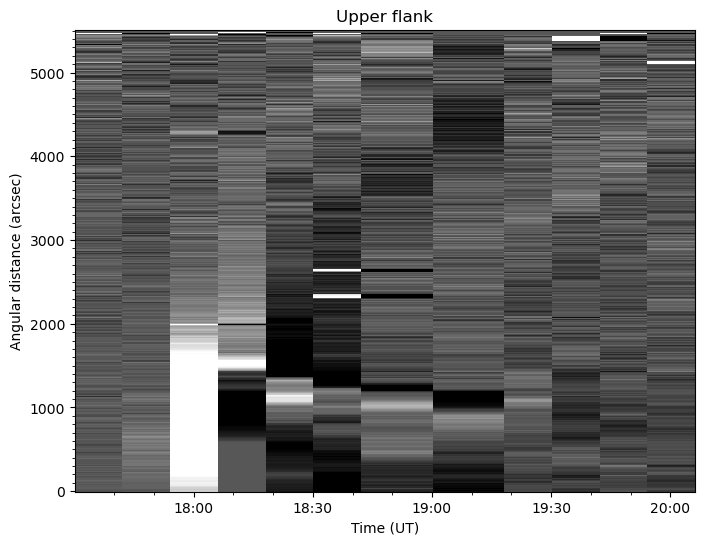

In [75]:
fig = plt.figure(figsize=[8,6])
ax = fig.add_subplot(111)
ax.pcolormesh(datenum_arr, distance_upper_flank, intens_upper_flank, vmin=0.7, vmax=1.8, cmap='Greys_r')
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Angular distance (arcsec)')
ax.set_title('Upper flank')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_minor_locator(AutoMinorLocator(n=3))
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
plt.show()

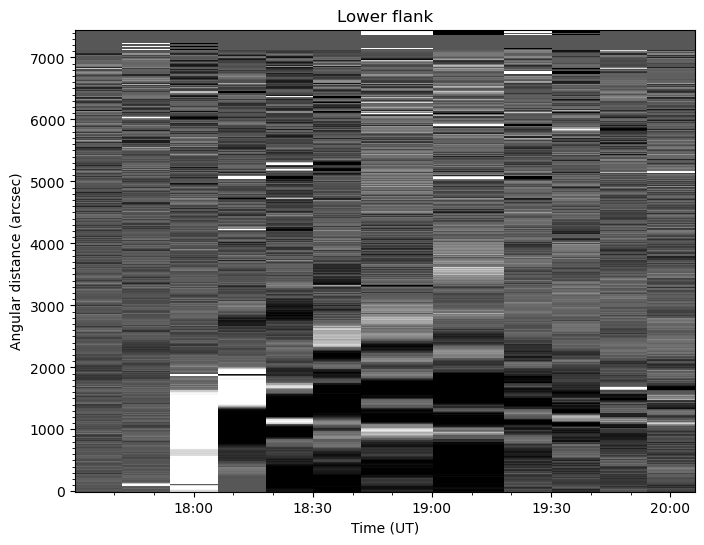

In [76]:
fig = plt.figure(figsize=[8,6])
ax = fig.add_subplot(111)
ax.pcolormesh(datenum_arr, distance_lower_flank, intens_lower_flank, vmin=0.7, vmax=1.8, cmap='Greys_r')
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Angular distance (arcsec)')
ax.set_title('Lower flank')
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_minor_locator(AutoMinorLocator(n=3))
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
plt.show()

### Clicking ...

In [ ]:
# initiate an empty dict to store the coords in each trial
num_repeats = 5

feature_coords_slit = {}
for i in range(num_repeats):
    feature_coords_slit[f'trial_{i}'] = []

print(feature_coords_slit)

In [ ]:
# Number of repetitions
num_repeats = 5
current_trial = 0

# Dictionary to store coordinates for each trial
feature_coords_slit = {f'trial_{i}': [] for i in range(num_repeats)}

# Text handle to update on the plot
text_handle = None

# plot the j-map
fig = plt.figure(figsize=[10,7])
ax = fig.add_subplot(111)
plt.ion()
ax.pcolormesh(datenum_arr, height, intens, vmin=0.7, vmax=1.8, cmap='Greys_r')
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Angular distance (arcsec)')
ax.set_title(f"J-plot of {output_obj['instrument'][0]} Intensity Along Slit {angle} deg")
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_minor_locator(AutoMinorLocator(n=3))
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlim(right=pd.Timestamp(f"{output_obj['time'][0].split(' ')[0]} 19:15:00"))
ax.set_ylim(bottom=2200)

# Connect the click event to the onclick function
cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show(block=False)
plt.pause(0.001)

In [ ]:
mean_values, standard_errors = compute_standard_error(feature_coords_slit)
x_mean, y_mean = zip(*mean_values)
x_err, y_err = zip(*standard_errors)

df = pd.DataFrame({'time': x_mean, 'distance': y_mean})
display(df)

In [ ]:
# fig = plt.figure(figsize=[10,7])
# ax = fig.add_subplot(111)
# ax.pcolormesh(datenum_arr, height, intens, vmin=0.7, vmax=1.8, cmap='Greys_r')

# ax.errorbar(x_mean, y_mean, xerr=x_err, yerr=y_err,
#             fmt='ro', ecolor='blue', barsabove=False,
#             markersize=4, elinewidth=1, capsize=3)

# ax.set_xlabel('Time (UT)')
# ax.set_ylabel('Angular distance (arcsec)')
# ax.set_title(f"J-plot of {output_obj['instrument'][0]} Intensity Along Slit {angle} deg")
# ax.xaxis_date()
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax.xaxis.set_minor_locator(AutoMinorLocator(n=3))
# ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
# ax.set_xlim(right=pd.Timestamp(f"{output_obj['time'][0].split(' ')[0]} 19:15:00"))
# ax.set_ylim(bottom=2200)
# plt.show()

In [ ]:
df.to_pickle(f"{savedir}/jplots/lasco_{detector}/clicking/jmap_{output_obj['instrument'][0]}_{output_obj['time'][0].split(' ')[0].replace('-','')}_slit_{angle}.pkl")
print(f"J-plot data saved at: {savedir}/jplots/lasco_{detector}/clicking/jmap_{output_obj['instrument'][0]}_{output_obj['time'][0].split(' ')[0].replace('-','')}_slit_{angle}.pkl")

### Fitting the points

In [ ]:
# Extract time and distance arrays from the selected coordinates
times_f, distances = zip(*mean_values)

# Convert times to matplotlib date numbers
times_num = np.array(times_f)

# Perform linear regression to fit a line
slope, intercept, r_value, p_value, std_err = stats.linregress(times_num, distances)

# get the radius of the solar disk
sol_rad = const.equatorial_radius.to(u.km)
print(sol_rad)

# conversion factor from arcsec to km
conversion_factor = sol_rad/output_obj['map_obj'][0].rsun_obs
print(conversion_factor)

In [ ]:
# convert distance from arcsec to km
df['distance_km'] = df['distance'] * conversion_factor

# calculate the distance difference in km
df['distance_diff_km'] = df['distance_km'].diff()

# convert time to datetime format
df['datetime'] = [mdates.num2date(t) for t in df['time']]

# calculate the time difference in seconds
df['time_diff_s'] = df['datetime'].diff().dt.total_seconds()

# calculate the speed in km/s
df['speed_km_s'] = df['distance_diff_km'] / df['time_diff_s']

# # drop the first row which will have NaN values for the differences
# df.dropna(inplace=True)

In [ ]:
# Calculate spline fit
spline = UnivariateSpline(times_num, distances, k=1, s=None)  # s=0 for interpolation through all points

# Generate the spline line
spline_times = np.linspace(min(times_num), max(times_num), 1000)
spline_distances = spline(spline_times)

# Calculate the derivative of spline_distances with respect to spline_times
spline_velocity = spline.derivative()(spline_times)

# Convert velocity (in arcsec/day) to speed in km/s
# 1 arcsec ≈ 733 km on the Sun's surface
# 1 day = 86400 seconds
speed_spline = spline_velocity * conversion_factor.value / 86400  # km/s

# Calculate the polynomial fit
polyfit_coeff = np.polyfit(times_num, distances, 2)  # Fit a 2nd order polynomial
polyfit_line = np.polyval(polyfit_coeff, spline_times)

# Calculate the derivative of the polynomial fit (velocity)
polyfit_velocity = np.polyval(np.polyder(polyfit_coeff), spline_times)
speed_polyfit = polyfit_velocity * conversion_factor.value / 86400  # km/s

In [ ]:
display(df)

In [ ]:
fig = plt.figure(figsize=[8,6])
ax = fig.add_subplot(111)
ax.pcolormesh(datenum_arr, height, intens, vmin=0.7, vmax=1.8, cmap='Greys_r')

# Plot the fitted line
fit_line = slope*times_num + intercept

# Calculate the speed (slope in arcsec/day to speed in km/s)
# 1 arcsec ≈ 733 km on the Sun's surface
# 1 day = 86400 seconds
speed_fit = slope * conversion_factor.value/86400  # km/s
speed = df['speed_km_s'].mean()

# Plot the selected points
ax.errorbar(x_mean, y_mean, xerr=x_err, yerr=y_err,
            fmt='ro', ecolor='blue', barsabove=False,
            markersize=4, elinewidth=1, capsize=3, label=f'Mean speed: {speed:.2f} km/s')

ax.plot(times_num, fit_line, ls='--', color='yellow',
        label=f'Linear fit: {speed_fit:.2f} km/s')

# Plot the spline fit line
ax.plot(spline_times, spline_distances, ls='--', color='tab:red',
        label=f'Spline fit: {np.nanmean(speed_spline):.2f} km/s')

# Plot the polynomial fit line
ax.plot(spline_times, polyfit_line, ls='-', color='tab:blue',
           label=f'2nd-order Polynomial fit: {np.nanmean(speed_polyfit):.2f} km/s')

ax.set_xlabel('Time (UT)')
ax.set_ylabel('Angular distance (arcsec)')
ax.set_title(f"J-plot of {output_obj['instrument'][0]} Intensity Along Slit {angle} deg.")
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_minor_locator(AutoMinorLocator(n=3))
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.legend(loc='lower right')
ax.set_xlim(right=pd.Timestamp(f"{output_obj['time'][0].split(' ')[0]} 19:15:00"))
ax.set_ylim(bottom=2200, top=6750)
fig.tight_layout()
plt.show()

# Doing all the slits one by one because the for-loop didn't work ...

In [ ]:
print(centered_list)

In [ ]:
angle = 172

height = output_obj[f'distances_{angle}deg'][0].copy()
intens = output_obj[f'intensity_{angle}deg'][0].copy()

print(f'Working on slit: {angle} deg.')

# Number of repetitions
num_repeats = 5
current_trial = 0

# Dictionary to store coordinates for each trial
feature_coords_slit = {f'trial_{i}': [] for i in range(num_repeats)}

# Text handle to update on the plot
text_handle = None

# plot the J-map
fig = plt.figure(figsize=[10,7])
ax = fig.add_subplot(111)
plt.ion()
ax.pcolormesh(datenum_arr, height, intens, vmin=0.7, vmax=1.8, cmap='Greys_r')
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Angular distance (arcsec)')
ax.set_title(f"J-plot of {output_obj['instrument'][0]} Intensity Along Slit {angle} deg.")
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_minor_locator(AutoMinorLocator(n=3))
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.set_xlim(right=pd.Timestamp(f"{output_obj['time'][0].split(' ')[0]} 19:15:00"))
ax.set_ylim(bottom=2200)

# Connect the click event to the onclick function
cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show(block=False)
plt.pause(0.001)

In [ ]:
# calc the standard error
mean_values, standard_errors = compute_standard_error(feature_coords_slit)

x_mean, y_mean = zip(*mean_values)
x_err, y_err = zip(*standard_errors)

event_date = output_obj['time'][0].split(' ')[0].replace('-','')
output_filename = f"jmap_{output_obj['instrument'][0]}_{event_date}_slit_{angle}"

df = pd.DataFrame({'time': x_mean, 'distance': y_mean,
                   'x_err': x_err, 'y_err': y_err})
# df.to_pickle(f'{savedir}/jplots/lasco_{detector}/clicking/coords_{output_filename}.pkl')

with open(f'{savedir}/jplots/lasco_{detector}/clicking/coords_{output_filename}.pkl', 'wb') as file:
    pickle.dump(feature_coords_slit, file)

# Extract time and distance arrays from the selected coordinates
times_num, distances = df['time'].values, df['distance'].values

# Perform linear regression to fit a line
slope, intercept, r_value, p_value, std_err = stats.linregress(times_num, distances)

# get the radius of the solar disk
sol_rad = const.equatorial_radius.to(u.km)

# conversion factor from arcsec to km
conversion_factor = sol_rad/output_obj['map_obj'][0].rsun_obs

# store the curve points with error bars
df['x_mean'] = x_mean
df['y_mean'] = y_mean
df['x_err'] = x_err
df['y_err'] = y_err

# convert distance from arcsec to km
df['distance_km'] = distances * conversion_factor.value

# calculate the distance difference in km
df['distance_diff_km'] = df['distance_km'].diff()

# convert time to datetime format
df['datetime'] = [mdates.num2date(t) for t in times_num]

# calculate the time difference in seconds
df['time_diff_s'] = df['datetime'].diff().dt.total_seconds()

# calculate the speed in km/s
df['speed_km_s'] = df['distance_diff_km'] / df['time_diff_s']

df.to_csv(f'{savedir}/jplots/lasco_{detector}/clicking/{output_filename}.csv')
print(f'J-plot data saved at: {savedir}/jplots/lasco_{detector}/clicking/{output_filename}.csv')

# # drop the first row which will have NaN values for the differences
# df.dropna(inplace=True)

# Calculate spline fit
spline = UnivariateSpline(times_num, distances, k=1, s=None) # s=0 for interpolation through all points

# Generate the spline line
spline_times = np.linspace(min(times_num), max(times_num), 1000)
spline_distances = spline(spline_times)

# Calculate the derivative of spline_distances with respect to spline_times
spline_velocity = spline.derivative()(spline_times)

# Convert velocity (in arcsec/day) to speed in km/s
# 1 arcsec ≈ 733 km on the Sun's surface
# 1 day = 86400 seconds
speed_spline = spline_velocity * conversion_factor.value / 86400  # km/s

# Calculate the polynomial fit
polyfit_coeff = np.polyfit(times_num, distances, 2)  # Fit a 2nd order polynomial
polyfit_line = np.polyval(polyfit_coeff, spline_times)

# Calculate the derivative of the polynomial fit (velocity)
polyfit_velocity = np.polyval(np.polyder(polyfit_coeff), spline_times)
speed_polyfit = polyfit_velocity * conversion_factor.value / 86400  # km/s

# show the final J-map with the fitting lines and speed estimations
fig = plt.figure(figsize=[8,6])
ax = fig.add_subplot(111)
ax.pcolormesh(datenum_arr, height, intens, vmin=0.7, vmax=1.8, cmap='Greys_r')

# Plot the fitted line
fit_line = slope*times_num + intercept

# Calculate the speed (slope in arcsec/day to speed in km/s)
speed_fit = slope * conversion_factor.value/86400  # km/s
speed = df['speed_km_s'].mean()

# Plot the selected points with error bars
ax.errorbar(x_mean, y_mean, xerr=x_err, yerr=y_err,
            fmt='ro', ecolor='blue', barsabove=False,
            markersize=4, elinewidth=1, capsize=3, label=f'Mean speed: {speed:.2f} km/s')

ax.plot(times_num, fit_line, ls='--', color='yellow',
        label=f'Linear fit: {speed_fit:.2f} km/s')

# Plot the spline fit line
ax.plot(spline_times, spline_distances, ls='--', color='tab:red',
        label=f'Spline fit: {np.nanmean(speed_spline):.2f} km/s')

# Plot the polynomial fit line
ax.plot(spline_times, polyfit_line, ls='-', color='tab:blue',
           label=f'2nd-order Polynomial fit: {np.nanmean(speed_polyfit):.2f} km/s')

ax.set_xlabel('Time (UT)')
ax.set_ylabel('Angular distance (arcsec)')
ax.set_title(f"J-plot of {output_obj['instrument'][0]} Intensity Along Slit {angle} deg.")
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_minor_locator(AutoMinorLocator(n=3))
ax.yaxis.set_minor_locator(AutoMinorLocator(n=10))
ax.legend(loc='lower right')
ax.set_xlim(right=pd.Timestamp(f"{output_obj['time'][0].split(' ')[0]} 19:15:00"))
ax.set_ylim(bottom=2200, top=6750)
fig.tight_layout()
png_filename = f'jmap_lasco_{detector}_{event_date}_slit_{angle}.png'
fig.savefig(f'{savedir}/jplots/lasco_{detector}/clicking/{png_filename}',
            format='png', bbox_inches='tight')
print(f'Figure: {png_filename} has been exported.\n')
plt.show()